# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("titanic_passengers.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


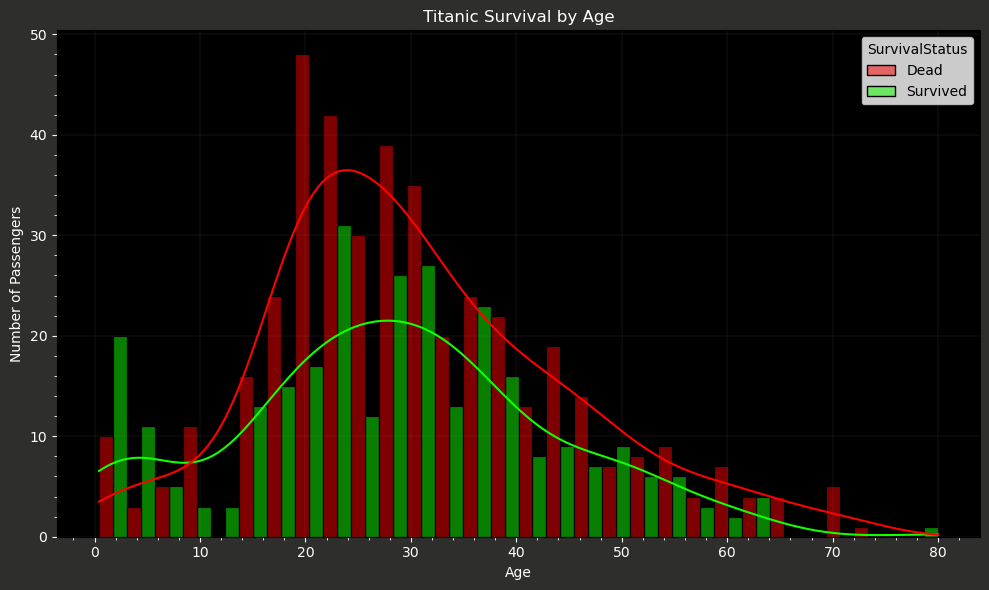

In [3]:
age_data = df[['Age', 'Survived']].dropna()

fig, ax = plt.subplots(figsize=(10, 6))

age_data.loc[age_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
age_data.loc[age_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

sns.histplot(data=age_data,x='Age',hue='SurvivalStatus',bins=30,kde=True,edgecolor='black',multiple="dodge",palette={"Dead": "#ff0000", "Survived": "#11ff00"})


fig.set_facecolor('#2e2e2d')  #2e2e2d
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.1, color='gray')
ax.grid(True, axis='x', linestyle='-', linewidth=.1, color='gray')
ax.tick_params(axis='both', which='minor', color='white')
ax.minorticks_on()
ax.set_title("Titanic Survival by Age", color='white')
ax.set_xlabel("Age", color='white')
ax.set_ylabel("Number of Passengers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()

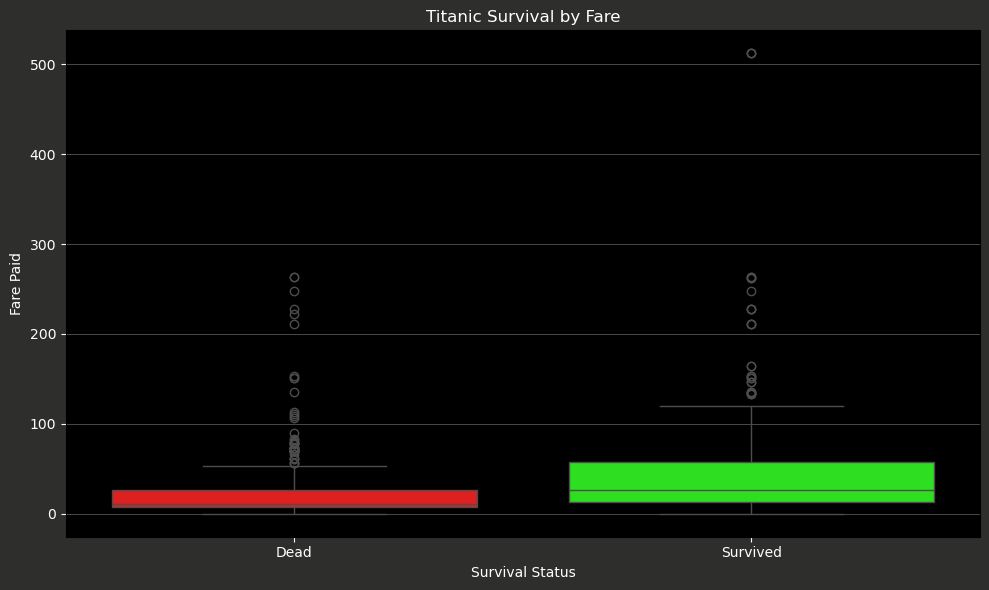

In [4]:

fare_data = df[['Fare', 'Survived']].dropna()


fare_data.loc[fare_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
fare_data.loc[fare_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=fare_data,x='SurvivalStatus',y ='Fare',hue='SurvivalStatus',legend=False,palette={"Dead": "#ff0000", "Survived": "#11ff00"})


fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Titanic Survival by Fare", color='white')
ax.set_xlabel("Survival Status", color='white')
ax.set_ylabel("Fare Paid", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


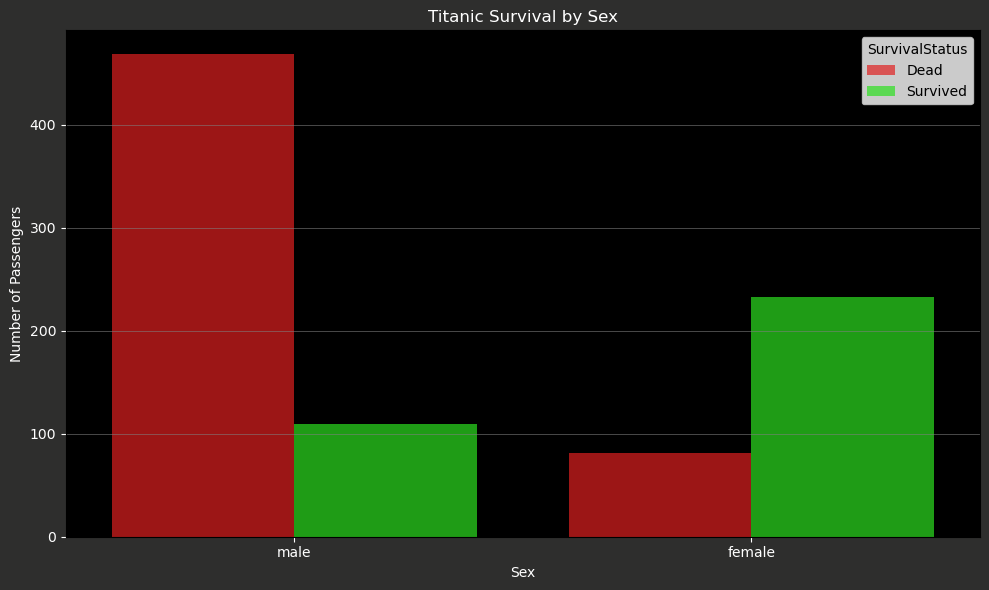

In [5]:

sex_data = df[['Sex', 'Survived']].dropna()


sex_data.loc[sex_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
sex_data.loc[sex_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

fig, ax = plt.subplots(figsize=(10, 6))


sns.countplot(data=sex_data,x='Sex',hue='SurvivalStatus',alpha = 0.7, palette={"Dead": "#ff0000", "Survived": "#11ff00"})

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Titanic Survival by Sex", color='white')
ax.set_xlabel("Sex", color='white')
ax.set_ylabel("Number of Passengers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()


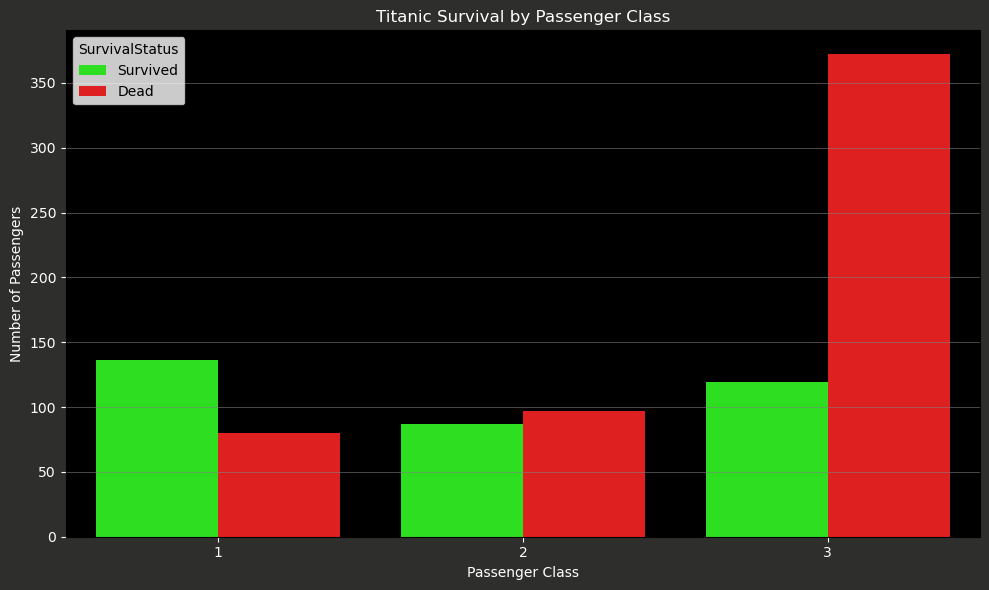

In [6]:
pclass_data = df[['Pclass', 'Survived']].dropna()
pclass_data.loc[pclass_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
pclass_data.loc[pclass_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=pclass_data,x='Pclass',hue='SurvivalStatus',palette={"Dead": "#ff0000", "Survived": "#11ff00"})

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Titanic Survival by Passenger Class", color='white')
ax.set_xlabel("Passenger Class", color='white')
ax.set_ylabel("Number of Passengers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()

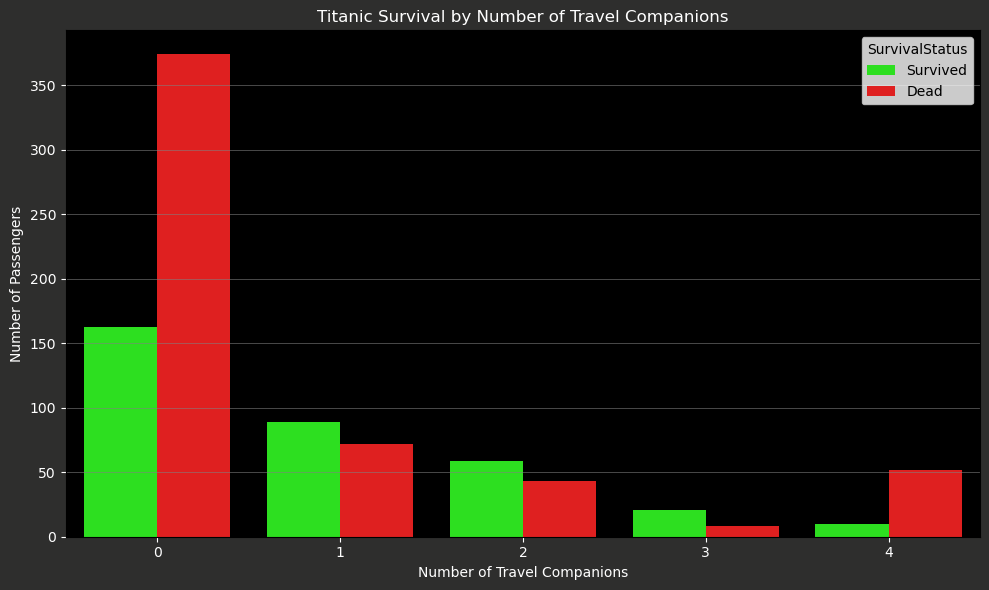

In [7]:
comp_data = df[['SibSp', 'Parch', 'Survived']].dropna()
comp_data['TravelCompanions'] = comp_data['SibSp'] + comp_data['Parch']

comp_data.loc[comp_data['TravelCompanions'] >= 4, 'TravelCompanions'] = 4
comp_data.loc[comp_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
comp_data.loc[comp_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    data=comp_data,
    x='TravelCompanions',
    hue='SurvivalStatus',
    palette={"Dead": "#ff0000", "Survived": "#11ff00"}
)

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Titanic Survival by Number of Travel Companions", color='white')
ax.set_xlabel("Number of Travel Companions", color='white')
ax.set_ylabel("Number of Passengers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()

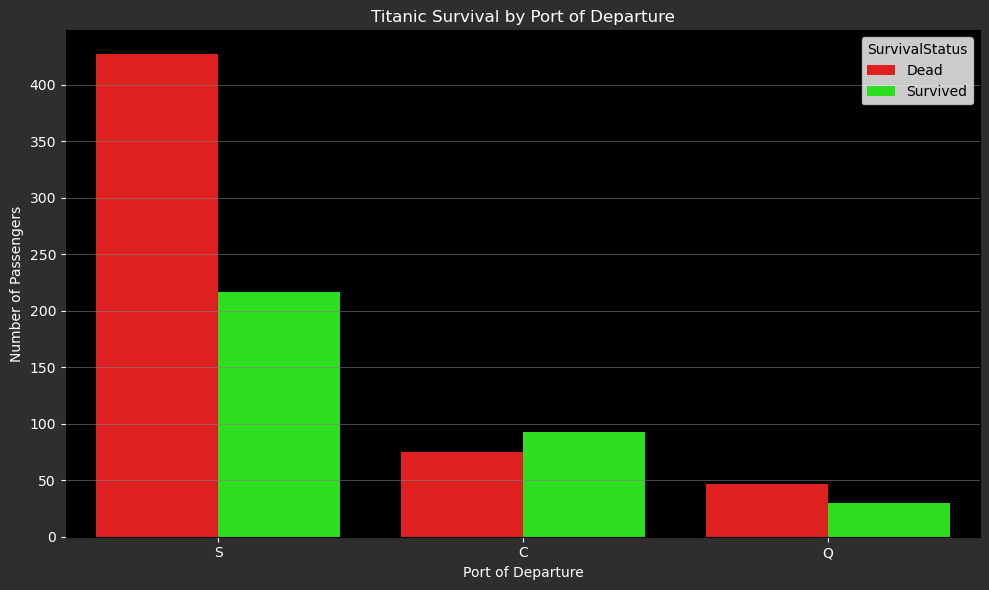

In [8]:
port_data = df[['Embarked', 'Survived']].dropna()

port_data.loc[port_data['Survived'] == 0, 'SurvivalStatus'] = "Dead"
port_data.loc[port_data['Survived'] == 1, 'SurvivalStatus'] = "Survived"

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=port_data,x='Embarked',hue='SurvivalStatus',palette={"Dead": "#ff0000", "Survived": "#11ff00"})

fig.set_facecolor('#2e2e2d')
ax.set_facecolor('black')

ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
ax.set_title("Titanic Survival by Port of Departure", color='white')
ax.set_xlabel("Port of Departure", color='white')
ax.set_ylabel("Number of Passengers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

plt.tight_layout()
plt.show()

In [10]:
# Most likely to survive
most_survive = df.loc[(df['Survived'] == 1) &(df['Sex'] == 'female') &(df['Pclass'] == 1) &(df['Age'].between(20, 35)) &(df['Fare'] > 50)]
print("Most likely to survive candidates:")
print(most_survive['Name'])

# Least likely to survive
least_survive = df.loc[(df['Survived'] == 0) &(df['Sex'] == 'male') &(df['Pclass'] == 3) &(df['Age'].between(30, 40)) &(df['Fare'] < 20)]
print("\nLeast likely to survive candidates:")
print(least_survive['Name'])


Most likely to survive candidates:
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
88                            Fortune, Miss. Mabel Helen
151                    Pears, Mrs. Thomas (Edith Wearne)
215                              Newell, Miss. Madeleine
218                                Bazzani, Miss. Albina
230         Harris, Mrs. Henry Birkhardt (Irene Wallach)
257                                 Cherry, Miss. Gladys
258                                     Ward, Miss. Anna
269                               Bissette, Miss. Amelia
290                         Barber, Miss. Ellen "Nellie"
309                       Francatelli, Miss. Laura Mabel
310                       Hays, Miss. Margaret Bechstein
318                             Wick, Miss. Mary Natalie
341                       Fortune, Miss. Alice Elizabeth
356                          Bowerman, Miss. Elsie Edith
369                        Aubart, Mme. Leontine Pauline
383    Holverson, Mrs. Alexander Oskar (Mary Aline To